Code to convince myself of what i am waiting/expecting with the correlation functions between X and Y analysis of Ot analysis of E.coli

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
from scipy.signal import chirp

In [2]:
%matplotlib widget


In [3]:
fs = 1e4
durations  =  2 #s
t_total  = np.linspace (0,durations, int(fs*durations))

# frequencies of the chirp
f0_1 = 60
f1_1 = 110
f0_2 = 110
f1_2 = 50

# Signal to Noise Ratio
snr_db = 10

Normal sinusoidal signals  X



In [4]:
#Amplitudes
A1, A2, A3 = 1.0, 1.0, 1.0
#Frequencies
f1, f2, f3 = 25.0, 100, 110

sine_signal_clean  = A1*np.sin(2*t_total*f1*np.pi) +  A2*np.sin(2*t_total*f2*np.pi) +  A3*np.sin(2*t_total*f3*np.pi)

sine_power = np.var(sine_signal_clean)
signal_noise_power = sine_power / (10**(snr_db/10))
noise_sine = np.sqrt(sine_power) * np.random.randn(len(sine_signal_clean)) 

sine_signal_noisy = sine_signal_clean + noise_sine

Same signal shifted by $\pi /2$ (Y)


In [5]:
sine_signal_clean_shifted  = A1*np.sin(2*t_total*f1*np.pi+(np.pi/2)) +  A2*np.sin(2*t_total*f2*np.pi+(np.pi/2)) +  A3*np.sin(2*t_total*f3*np.pi+(np.pi/2))

noise_sine_2 =  np.sqrt(sine_power) * np.random.randn(len(sine_signal_clean_shifted)) 

sine_signal_noisy_shifted = sine_signal_clean_shifted + noise_sine_2

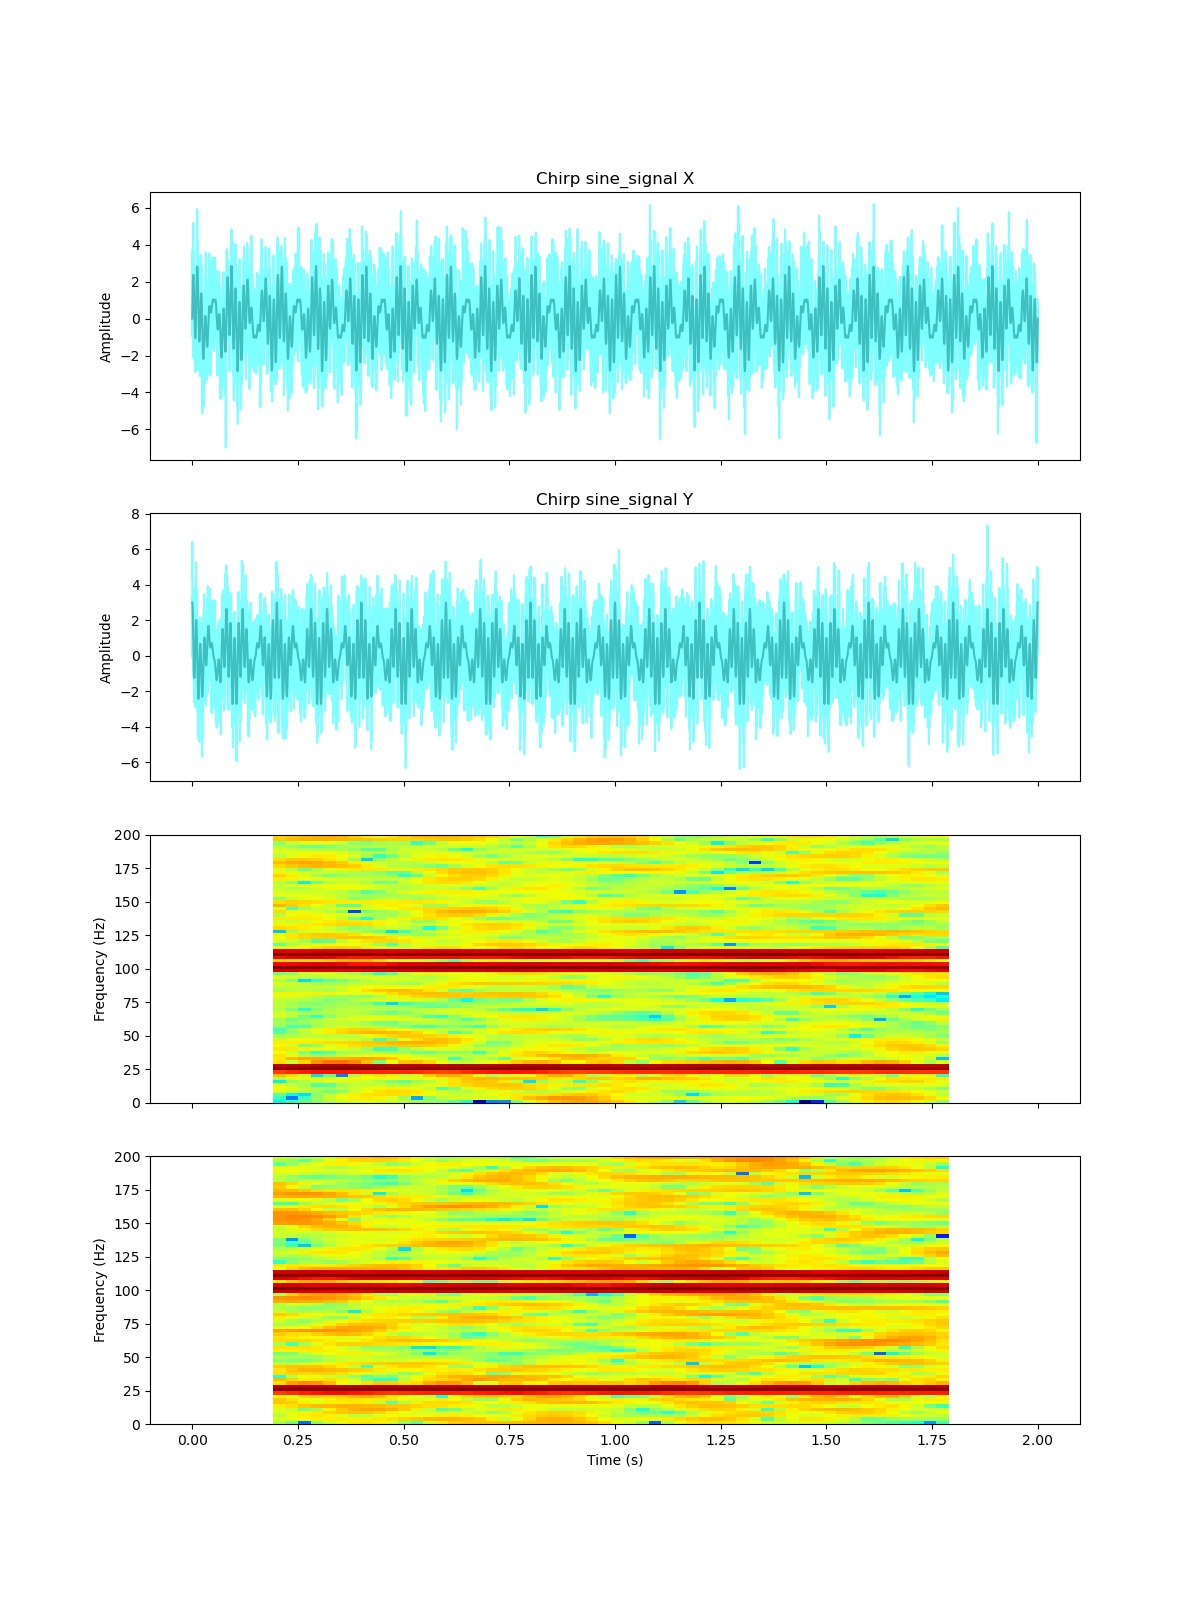

In [6]:
fig , axes = plt.subplots(4,1, figsize=(12,16), num ='Sine signal', sharex=True)

axes[0].plot(t_total , sine_signal_clean, color = 'black', alpha = 0.5)
axes[0].plot(t_total , sine_signal_noisy, color = 'cyan', alpha = 0.5)
axes[0].set_title ('Chirp sine_signal X')
axes[0].set_ylabel('Amplitude')

axes[1].plot(t_total , sine_signal_clean_shifted, color = 'black', alpha = 0.5)
axes[1].plot(t_total , sine_signal_noisy_shifted, color = 'cyan', alpha = 0.5)
axes[1].set_title ('Chirp sine_signal Y')
axes[1].set_ylabel('Amplitude')


axes[2].specgram(sine_signal_noisy, Fs = fs, NFFT = 4096, noverlap = 3800, cmap = 'jet')
axes[2].set_ylabel('Frequency (Hz)')
axes[2].set_ylim(0, 200) 

axes[3].specgram(sine_signal_noisy_shifted, Fs = fs, NFFT = 4096, noverlap = 3800, cmap = 'jet')
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('Frequency (Hz)')
axes[3].set_ylim(0, 200)

plt.show()

A signal with a certain SNR, consider to be my x signal 

In [7]:
## split into two segments to have a chirp that goes from 60 Hz to 110 Hz then to 50 Hz again

half = len(t_total)//2
t1 = t_total[:half]
t2 = t_total[half:]

segment1 = chirp(t1, f0 = f0_1, f1 = f1_1, t1 = t1[-1], method ='linear')
segment2 = chirp(t2, f0 = f0_2, f1 = f1_2, t1 = t2[-1], method ='linear')


signal_clean = np.concatenate([segment1,segment2])

# Gaussian white noise

signal_power = np.var(signal_clean)
noise_power = signal_power / ( 10 **(snr_db /10))
noise = np.sqrt(noise_power) * np.random.randn(len(signal_clean))


signal_noisy = signal_clean + noise


The same signal with an offset of $\pi /2$ and noise with the same SNR (will be my Y signal
)


In [8]:
seg1_shifted = chirp(t1, f0 = f0_1, f1 = f1_1, t1 = t1[-1], method ='linear', phi = -90)
seg2_shifted = chirp(t2, f0 = f0_2, f1 = f1_2, t1 = t2[-1], method ='linear', phi = -90)

signal_clean_shifted = np.concatenate([seg1_shifted, seg2_shifted])

noise2 = np.sqrt(noise_power) * np.random.randn(len(signal_clean_shifted))

signal_noisy_shifted = signal_clean_shifted + noise2

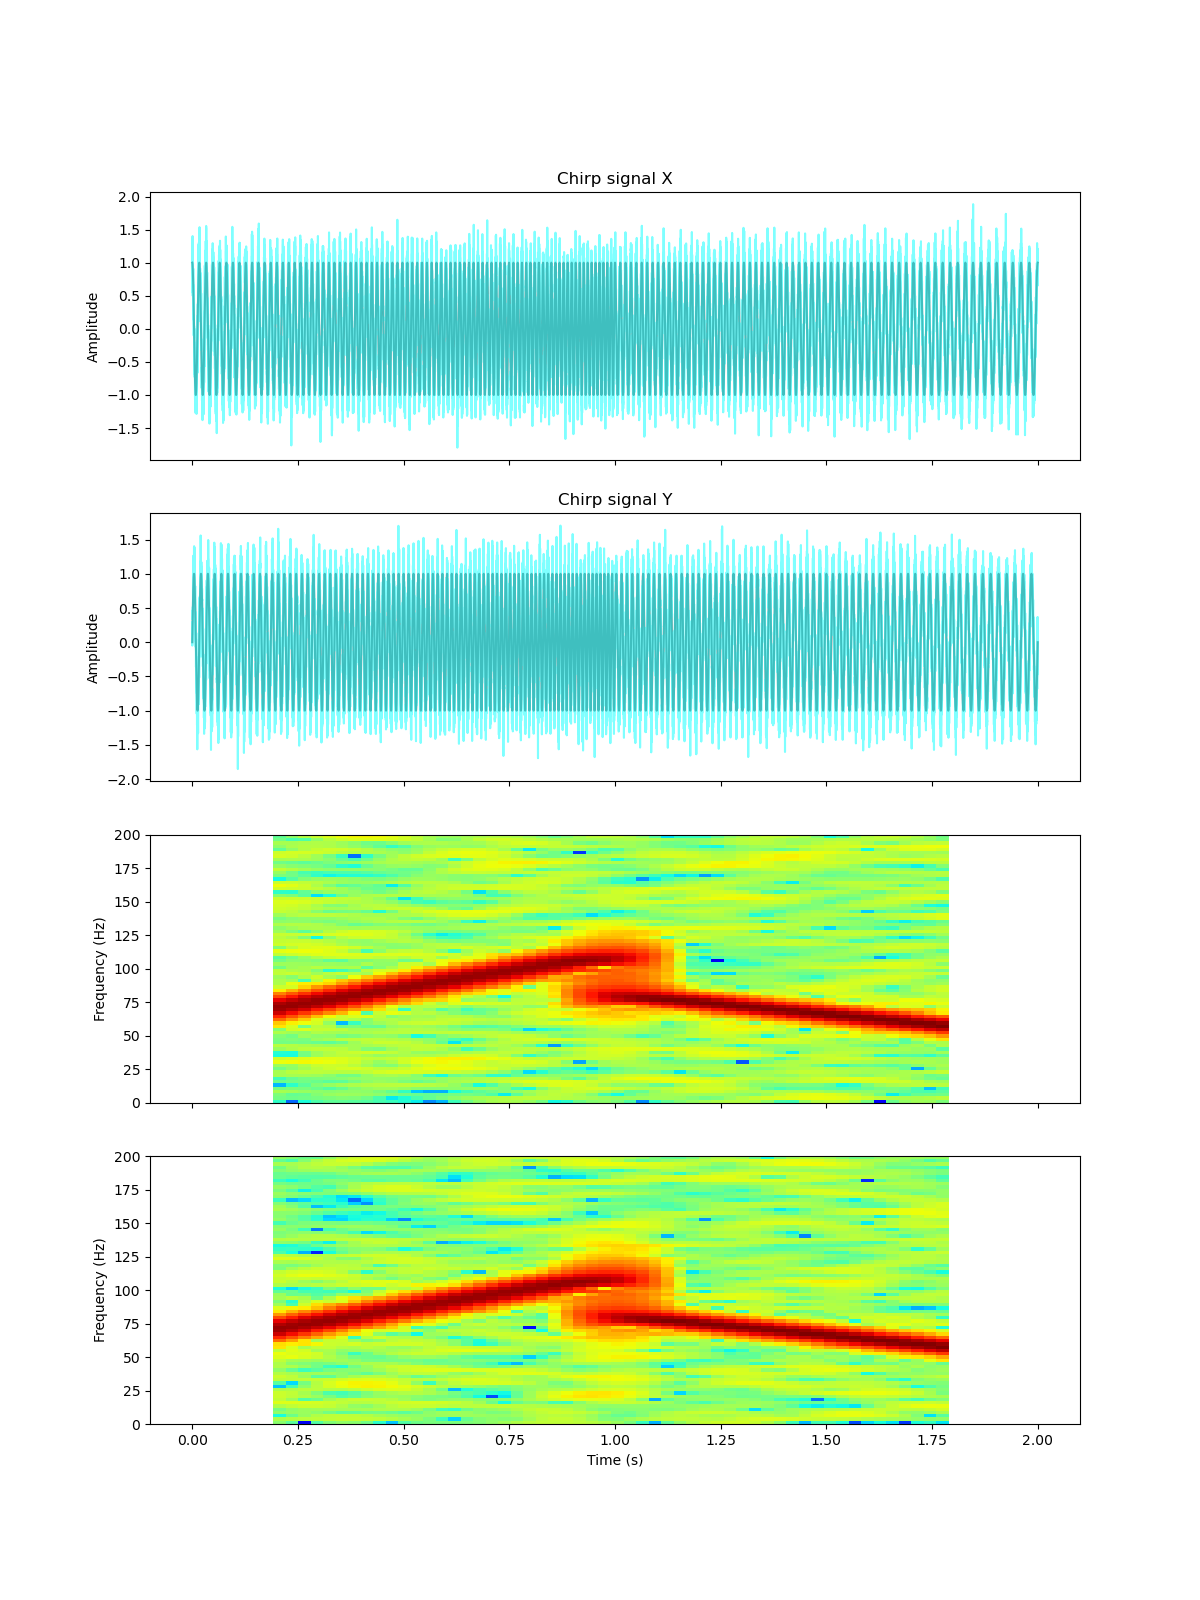

In [9]:
fig , axes = plt.subplots(4,1, figsize=(12,16), num ='Chirp', sharex=True)

axes[0].plot(t_total , signal_clean, color = 'black', alpha = 0.5)
axes[0].plot(t_total , signal_noisy, color = 'cyan', alpha = 0.5)
axes[0].set_title ('Chirp signal X')
axes[0].set_ylabel('Amplitude')

axes[1].plot(t_total , signal_clean_shifted, color = 'black', alpha = 0.5)
axes[1].plot(t_total , signal_noisy_shifted, color = 'cyan', alpha = 0.5)
axes[1].set_title ('Chirp signal Y')
axes[1].set_ylabel('Amplitude')


axes[2].specgram(signal_noisy, Fs = fs, NFFT = 4096, noverlap = 3800, cmap = 'jet')
axes[2].set_ylabel('Frequency (Hz)')
axes[2].set_ylim(0, 200) 

axes[3].specgram(signal_noisy_shifted, Fs = fs, NFFT = 4096, noverlap = 3800, cmap = 'jet')
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('Frequency (Hz)')
axes[3].set_ylim(0, 200)

plt.show()

Just to be sure of the offset


In [10]:
plt.plot(t_total[:200], signal_noisy[:200], label='original')
plt.plot(t_total[:200], signal_noisy_shifted[:200], label='shifted pi/2')
plt.legend()


### Now let's see what happend when  we correlate the signal with itself and the signal with the shifted signal

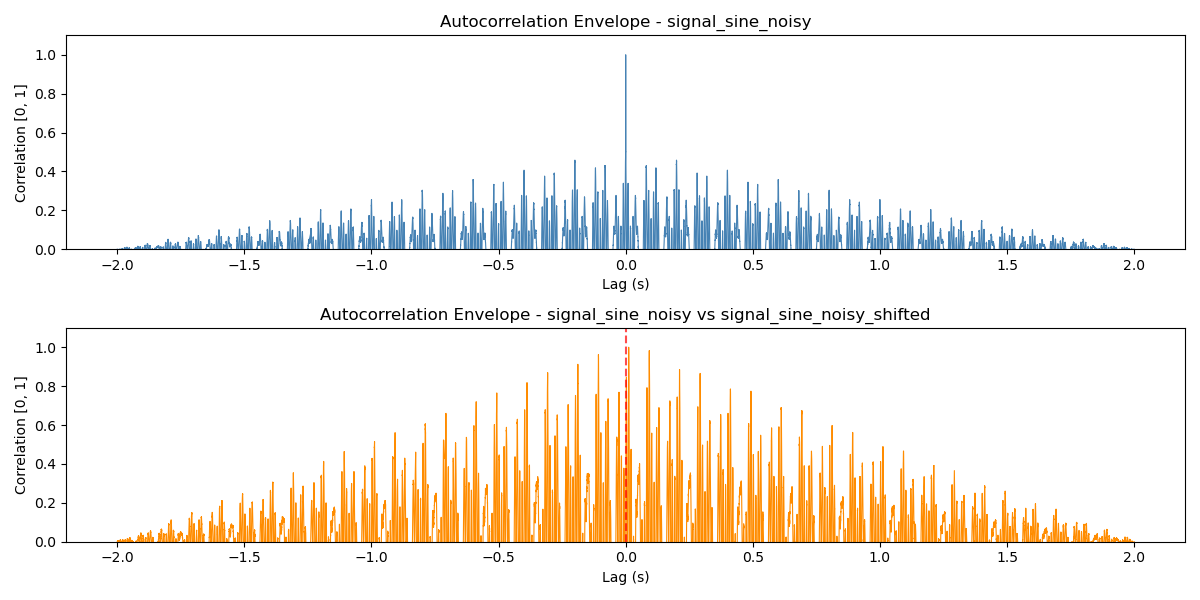

In [11]:
from scipy.signal import correlate, correlation_lags

# Autocorrelation
autocorr = correlate(sine_signal_noisy, sine_signal_noisy, mode='full')
# Normalized autocorrelation
autocorr_norm = autocorr / autocorr.max()

lags_auto = correlation_lags(len(sine_signal_noisy), len(sine_signal_noisy), mode='full')
t_lags_auto = lags_auto / fs

# Cross-correlation
crosscorr = correlate(sine_signal_noisy, sine_signal_noisy_shifted, mode='full')
# Normalized cross-correlation
crosscorr_norm = crosscorr / crosscorr.max()

lags_cross = correlation_lags(len(sine_signal_noisy), len(sine_signal_noisy_shifted), mode='full')
t_lags_cross = lags_cross / fs

from scipy.signal import hilbert

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t_lags_auto, autocorr_norm, color='steelblue', linewidth=0.8)
axes[0].set_title('Autocorrelation Envelope - signal_sine_noisy')
axes[0].set_xlabel('Lag (s)')
axes[0].set_ylabel('Correlation [0, 1]')
axes[0].set_ylim(0, 1.1)

axes[1].plot(t_lags_cross, crosscorr_norm, color='darkorange', linewidth=0.8)
axes[1].set_title('Autocorrelation Envelope - signal_sine_noisy vs signal_sine_noisy_shifted')
axes[1].set_xlabel('Lag (s)')
axes[1].set_ylabel('Correlation [0, 1]')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()



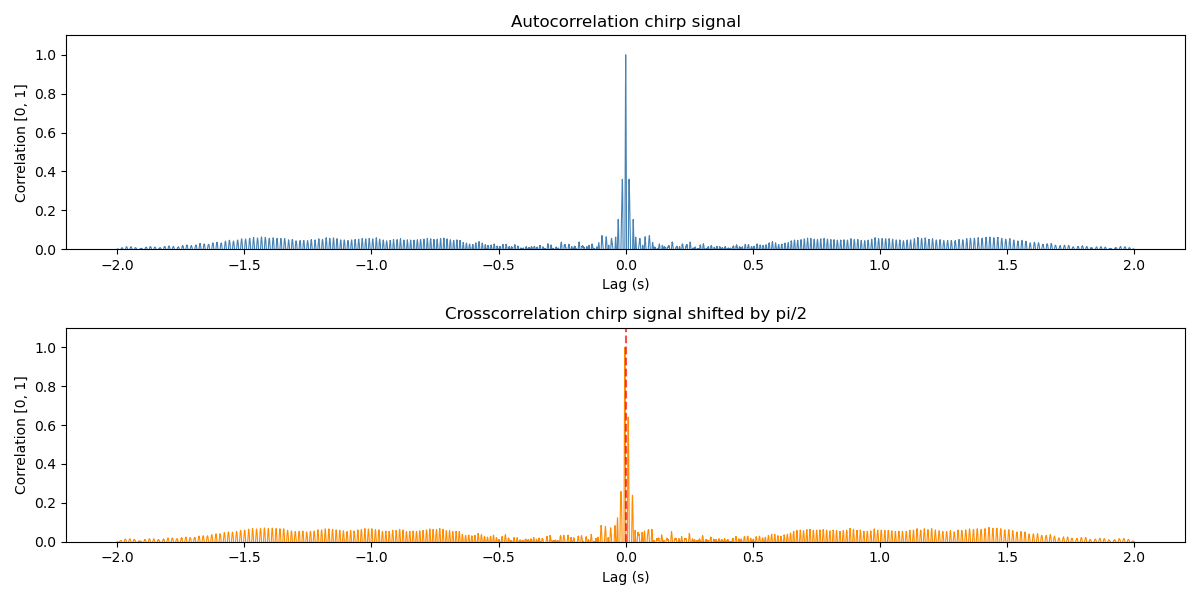

In [12]:
from scipy.signal import correlate, correlation_lags

# Autocorrelation
autocorr = correlate(signal_noisy, signal_noisy, mode='full')
# Normalized autocorrelation
autocorr_norm = autocorr / autocorr.max()

lags_auto = correlation_lags(len(signal_noisy), len(signal_noisy), mode='full')
t_lags_auto = lags_auto / fs

# Cross-correlation
crosscorr = correlate(signal_noisy, signal_noisy_shifted, mode='full')
# Normalized cross-correlation
crosscorr_norm = crosscorr / crosscorr.max()

lags_cross = correlation_lags(len(signal_noisy), len(signal_noisy_shifted), mode='full')
t_lags_cross = lags_cross / fs

from scipy.signal import hilbert

# Envelope via Hilbert transform
autocorr_env = np.abs(hilbert(autocorr_norm))
crosscorr_env = np.abs(hilbert(crosscorr_norm))

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 6), num ='Correlation sine waves')

axes[0].plot(t_lags_auto, autocorr_norm, color='steelblue', linewidth=0.8)
axes[0].set_title('Autocorrelation chirp signal')
axes[0].set_xlabel('Lag (s)')
axes[0].set_ylabel('Correlation [0, 1]')
axes[0].set_ylim(0, 1.1)

axes[1].plot(t_lags_cross, crosscorr_norm, color='darkorange', linewidth=0.8)
axes[1].set_title('Crosscorrelation chirp signal shifted by pi/2')
axes[1].set_xlabel('Lag (s)')
axes[1].set_ylabel('Correlation [0, 1]')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()




Ok now let's try to make a signal that has sine waves but also random noise segments


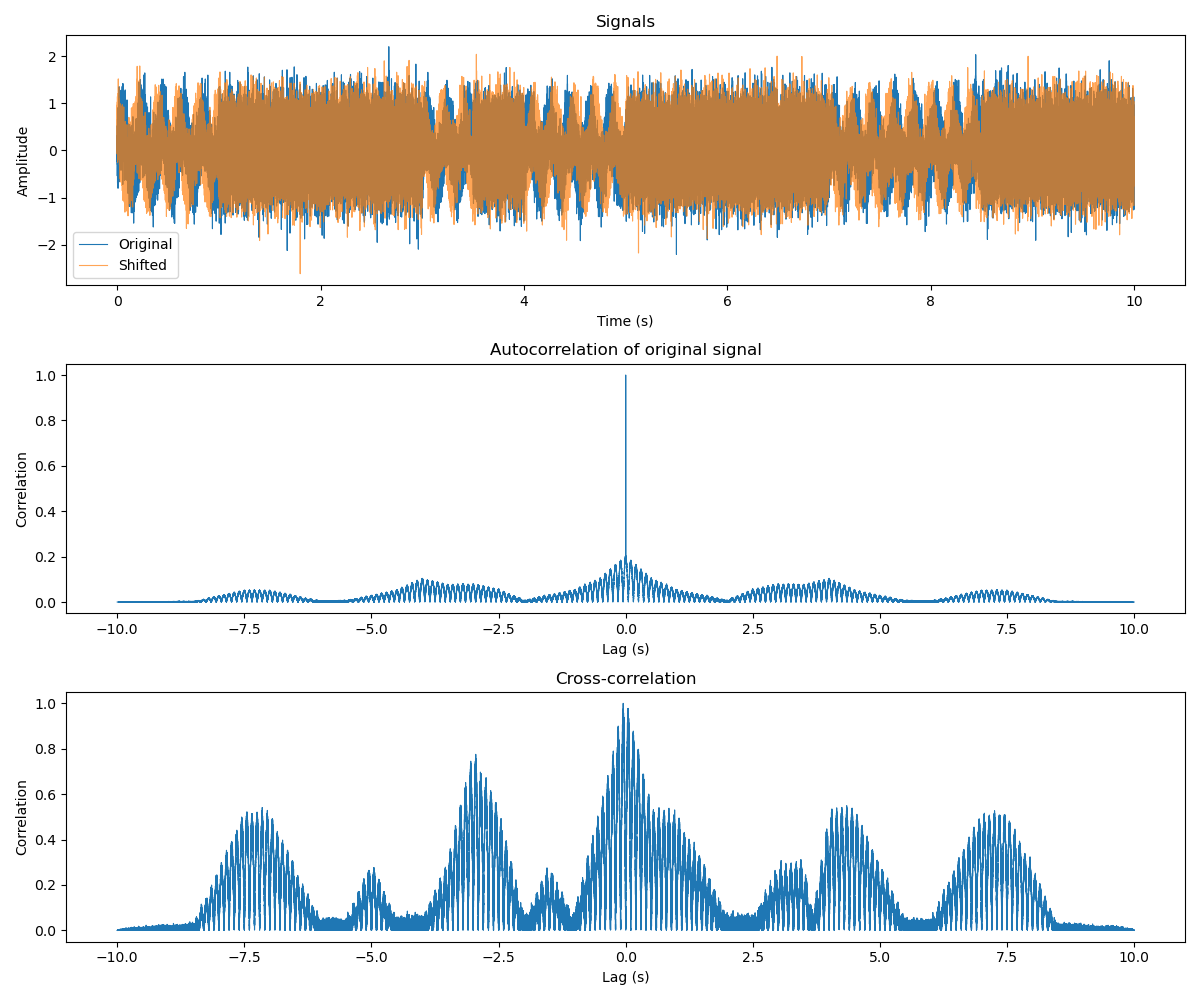

In [13]:
from scipy.signal import correlate, correlation_lags

def build_signals(fs=10000, duration=10, freq=5, amplitude=0.5, noise_std=0.5,
                  snr_db=0, phase_shift=np.pi/2, segments=None):
    """
    Build two segmented signals (original + phase shifted) with noise.
    Segments can have phase direction: +1 (forward) or -1 (backward).
    """
    dt = 1 / fs
    t  = np.arange(0, duration, dt)

    if segments is None:
        segments = [
            (0,   1,   'sine',  +1),   # phase = +pi/2
            (1,   3,   'noise',  0),
            (3,   3.5, 'sine',  +1),   # phase = +pi/2
            (3.5, 4,   'noise',  0),
            (4,   5,   'sine',  -1),   # phase = -pi/2  ← reversed direction
            (5,   7,   'noise',  0),
            (7,   8.5, 'sine',  +1),   # phase = +pi/2  ← back to forward
            (8.5, 10,  'noise',  0),
        ]

    # SNR calculation
    snr_linear     = 10 ** (snr_db / 10)
    sine_power     = amplitude**2 / 2
    noise_std_sine = np.sqrt(sine_power / snr_linear)

    signal         = np.zeros(len(t))
    signal_shifted = np.zeros(len(t))

    for seg in segments:
        t_start, t_end, seg_type = seg[0], seg[1], seg[2]
        direction = seg[3] if len(seg) > 3 else +1  # default forward

        idx = (t >= t_start) & (t < t_end)

        if seg_type == 'sine':
            clean          = amplitude * np.sin(2 * np.pi * freq * t[idx])
            signal[idx]    = clean + np.random.normal(0, noise_std_sine, np.sum(idx))

            # direction controls +phase_shift or -phase_shift
            actual_shift        = direction * phase_shift
            clean_shifted       = amplitude * np.sin(2 * np.pi * freq * t[idx] + actual_shift)
            signal_shifted[idx] = clean_shifted + np.random.normal(0, noise_std_sine, np.sum(idx))

        elif seg_type == 'noise':
            signal[idx]         = np.random.normal(0, noise_std, np.sum(idx))
            signal_shifted[idx] = np.random.normal(0, noise_std, np.sum(idx))

    return t, signal, signal_shifted, segments


def plot_correlations(t, signal, signal_shifted, fs):
    """
    Plot signals, autocorrelation and cross-correlation.
    """
    dt = 1 / fs

    # Autocorrelation
    autocorr = correlate(signal, signal, mode='full')
    lags_auto = correlation_lags(len(signal), len(signal), mode='full')
    autocorr_norm = autocorr / np.max(np.abs(autocorr))

    # Cross-correlation
    crosscorr = correlate(signal, signal_shifted, mode='full')
    lags_cross = correlation_lags(len(signal), len(signal_shifted), mode='full')
    crosscorr_norm = crosscorr / np.max(np.abs(crosscorr))

    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    axes[0].plot(t, signal, label='Original', lw=0.8)
    axes[0].plot(t, signal_shifted, label=f'Shifted', lw=0.8, alpha=0.7)
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title('Signals')
    axes[0].legend()

    axes[1].plot(lags_auto * dt, np.abs(autocorr_norm), lw=0.8)
    axes[1].set_xlabel('Lag (s)')
    axes[1].set_ylabel('Correlation')
    axes[1].set_title('Autocorrelation of original signal')

    axes[2].plot(lags_cross * dt, np.abs(crosscorr_norm), lw=0.8)
    axes[2].set_xlabel('Lag (s)')
    axes[2].set_ylabel('Correlation')
    axes[2].set_title('Cross-correlation')

    plt.tight_layout()
    plt.show()


# ── Run everything ──────────────────────────────────────────────
t, signal, signal_shifted, segments = build_signals(
    fs=10000, duration=10, freq=5, amplitude=0.5,
    noise_std=0.5, snr_db=0, phase_shift=np.pi/2
)

plot_correlations(t, signal, signal_shifted, fs=10000)



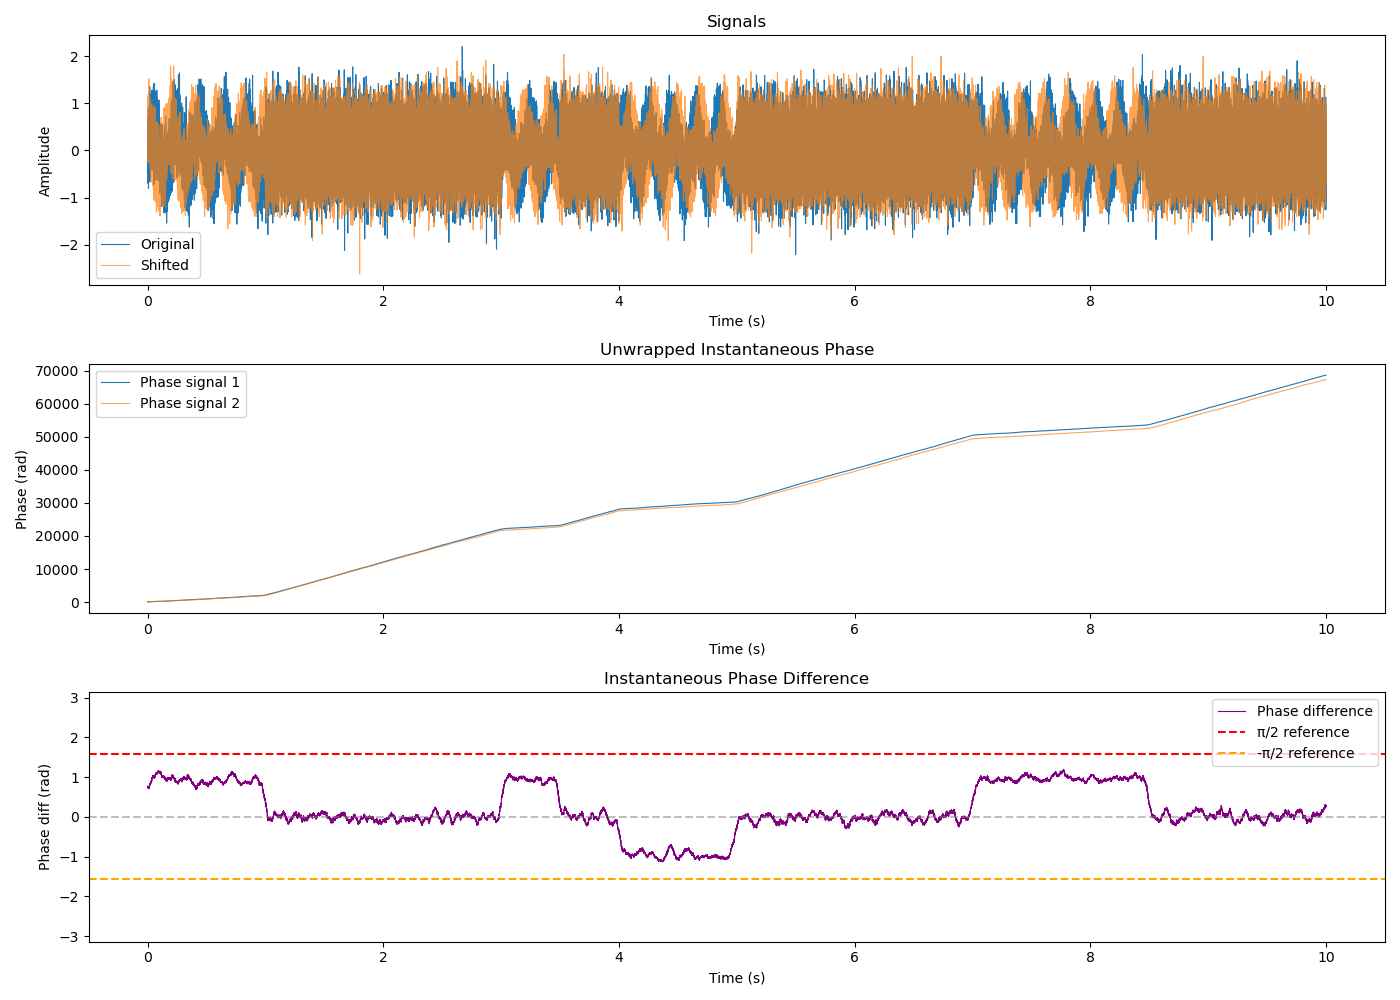

In [14]:
from scipy.signal import hilbert
from scipy.ndimage import uniform_filter1d


def phase_shift_analysis(signal, signal_shifted, t, fs):
    """
    Compute instantaneous phase difference between two signals.
    """
    # Analytic signal via Hilbert transform
    analytic1 = hilbert(signal)
    analytic2 = hilbert(signal_shifted)

    # Instantaneous phase
    phase1 = np.unwrap(np.angle(analytic1))
    phase2 = np.unwrap(np.angle(analytic2))

    # Phase difference
    phase_diff = phase2 - phase1

    # Wrap to [-pi, pi]
    phase_diff_wrapped = (phase_diff + np.pi) % (2 * np.pi) - np.pi

    # Amplitude envelope via Hilbert
    envelope1 = np.abs(hilbert(signal))
    envelope2 = np.abs(hilbert(signal_shifted))

    # Threshold: only keep points where both signals have enough energy
    threshold = 0.2  # tune this
    mask = (envelope1 > threshold) & (envelope2 > threshold)

    # Then smooth only valid parts
    phase_diff_smooth = uniform_filter1d(
        np.where(mask, phase_diff_wrapped, 0), size=int(fs * 0.05)
    )
    phase_diff_smooth = np.where(mask, phase_diff_smooth, np.nan)


    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Original signals
    axes[0].plot(t, signal, lw=0.8, label='Original')
    axes[0].plot(t, signal_shifted, lw=0.8, alpha=0.7, label='Shifted')
    axes[0].set_title('Signals')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].legend()

    # Unwrapped phase of each signal
    axes[1].plot(t, phase1, lw=0.8, label='Phase signal 1')
    axes[1].plot(t, phase2, lw=0.8, label='Phase signal 2', alpha=0.7)
    axes[1].set_title('Unwrapped Instantaneous Phase')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Phase (rad)')
    axes[1].legend()

    # Phase difference
    axes[2].plot(t, phase_diff_smooth, lw=0.8, color='purple', label='Phase difference')
    axes[2].axhline(np.pi/2, color='red', linestyle='--', label='π/2 reference')
    axes[2].axhline(-np.pi/2, color='orange', linestyle='--', label='-π/2 reference')
    axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[2].set_title('Instantaneous Phase Difference')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Phase diff (rad)')
    axes[2].set_ylim(-np.pi, np.pi)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    return phase_diff_wrapped

# Run it
phase_diff = phase_shift_analysis(signal, signal_shifted, t, fs)
